In [49]:
import numpy as np
from utils import plot
import math
import matplotlib.pyplot as plt

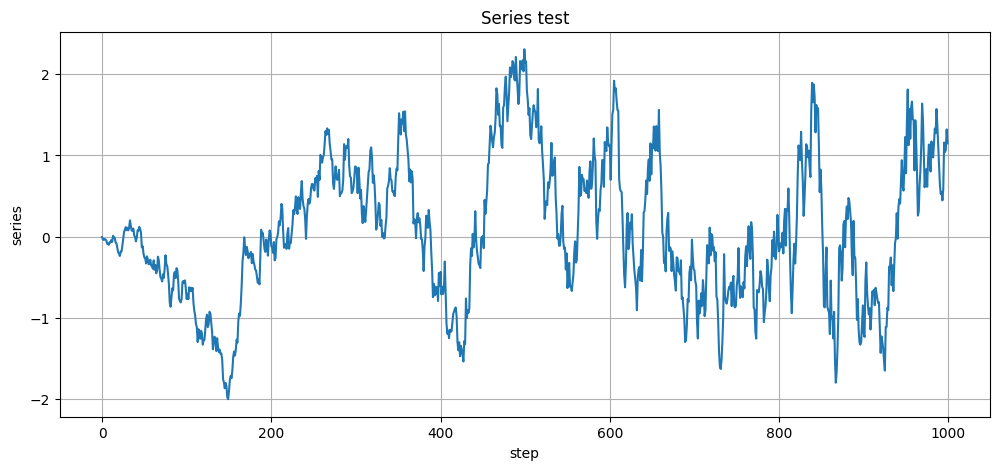

-0.015723784034096147
-0.035190648932298674


In [50]:
n = 1000

k = 0.01

t = np.arange(1, n + 1)

sigma = k * np.sqrt(t)

steps = np.random.normal(loc=0, scale=sigma)

x = np.cumsum(steps)

plot(
    None,
    x,
    'step',
    'series',
    'Series test'
)

s1 = x[0] + 2*x[1]
s2 = x[0] + x[1]
print(s1 - 1.5*s2)

s1 = x[0] + 2*x[1] + 3*x[2]
s2 = x[0] + x[1] + x[2]
print(s1 - 2*s2)

In [51]:
h = 100

In [52]:
print(2 % 3)
print((2 - 3) % 3)

2
2


In [53]:
def get_average_gain(series, step_count, horizon):
    n = min(step_count + 1, horizon)
    
    if n == 1:
        return 0
    
    sum_1 = 0
    sum_2 = 0
    i_0 = step_count % horizon
    mu = (n + 1)/2

    for i in range(n):
        idx = (i_0 - i) % n
        sum_1 += (n - i - mu)*series[idx]
        sum_2 += (i + 1 - mu)**2

    #print(sum_1, sum_2)

    return sum_1 / sum_2

In [54]:
slope_1 = []
partial_array_1 = np.zeros(h)

for i in range(n):
    partial_array_1[i % h] = x[i]

    a1 = get_average_gain(partial_array_1, i, h)
    slope_1.append(a1)

In [55]:
def get_slope(x, n, h):    
    slope_2 = []
    partial_array_2 = np.zeros(h)

    for step in range(n):
        old_x = partial_array_2[step % h]
        partial_array_2[step % h] = x[step]

        m = min(step + 1, h)

        if m == 1:
            sum_1 = x[step]
            sum_2 = x[step]
            a2 = 0
            is_first_time = True
        else:
            if m < h:
                sum_1 = sum_1 + m*x[step]
                sum_2 = sum_2 + x[step]
            else:
                if is_first_time:
                    sum_1 = sum_1 + m*x[step]
                    sum_2 = sum_2 + x[step]
                    is_first_time = False
                else:
                    sum_1 = sum_1 - sum_2 + m*x[step]
                    sum_2 = sum_2 - old_x + x[step]
                
            mu = (m + 1)/2
            denom = m*(m**2 - 1)/12

            a2 = (sum_1 - mu*sum_2)/denom
        
            #print(sum_1 - mu*sum_2, denom)
        slope_2.append(a2)
    
    return slope_2

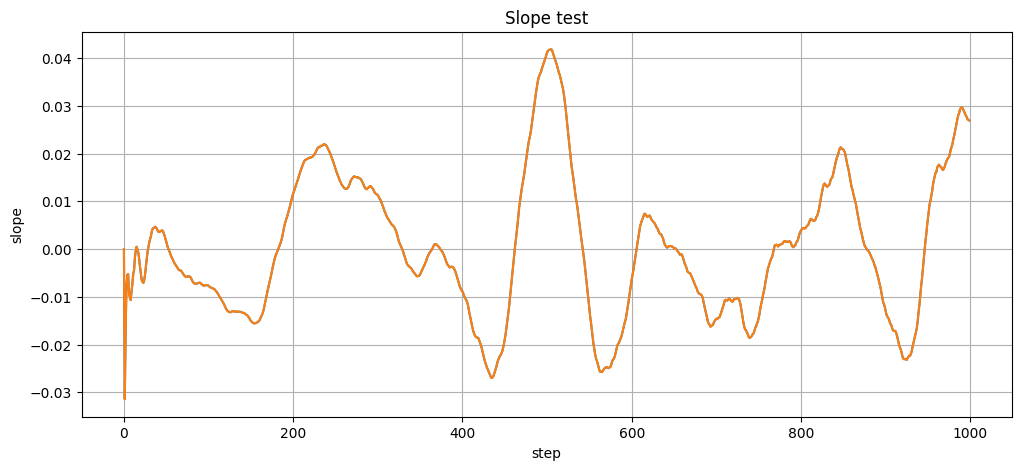

In [56]:
slope_2 = get_slope(x, n, h)

plt.figure(figsize=(12, 5))
plt.plot(slope_1)
plt.plot(slope_2)
plt.xlabel('step')
plt.ylabel('slope')
plt.title('Slope test')
plt.grid(True)
plt.show()

In [57]:
def get_series_dynamics_clear(x, n, h):    
    slope_2 = []
    mean = []
    sigma = []
    partial_array_2 = np.zeros(h)

    for step in range(n):
        old_x = partial_array_2[step % h]
        partial_array_2[step % h] = x[step]

        m = min(step + 1, h)

        if m == 1:
            sum_1 = x[step]
            sum_2 = x[step]
            sum_3 = x[step]**2
            a2 = 0
            a1 = x[step]
            a3 = 0
            is_first_time = True
        else:
            if m < h:
                sum_1 = sum_1 + m*x[step]
                sum_2 = sum_2 + x[step]
                sum_3 = sum_3 + x[step]**2
            else:
                if is_first_time:
                    sum_1 = sum_1 + m*x[step]
                    sum_2 = sum_2 + x[step]
                    sum_3 = sum_3 + x[step]**2
                    is_first_time = False
                else:
                    sum_1 = sum_1 - sum_2 + m*x[step]
                    sum_2 = sum_2 - old_x + x[step]
                    sum_3 = sum_3 - old_x**2 + x[step]**2
                
            mu = (m + 1)/2
            denom = m*(m**2 - 1)/12

            a1 = sum_2/m
            a2 = (sum_1 - mu*sum_2)/denom
            a3 = math.sqrt(max(0, sum_3/m - a1**2))
        
            #print(sum_1 - mu*sum_2, denom)
        slope_2.append(a2)
        mean.append(a1)
        sigma.append(a3)
    
    return mean, slope_2, sigma

def get_series_dynamics_with_break(x, n, h, breaks = None, delta = 1): 
    x = x.copy()   
    slope_2 = []
    mean = []
    sigma = []
    partial_array_2 = np.zeros(h)

    for step in range(n):

        if breaks is not None:
            if step in breaks:
                x[step:] += delta
                partial_array_2 += delta
                mu = (m + 1)/2

                sum_3 = sum_3 + 2*delta*sum_2 + m*delta**2
                sum_2 = sum_2 + m*delta
                sum_1 = sum_1 + m*mu*delta

        old_x = partial_array_2[step % h]
        partial_array_2[step % h] = x[step]

        m = min(step + 1, h)

        if m == 1:
            sum_1 = x[step]
            sum_2 = x[step]
            sum_3 = x[step]**2
            a2 = 0
            a1 = x[step]
            a3 = 0
            is_first_time = True
        else:
            if m < h:
                sum_1 = sum_1 + m*x[step]
                sum_2 = sum_2 + x[step]
                sum_3 = sum_3 + x[step]**2
            else:
                if is_first_time:
                    sum_1 = sum_1 + m*x[step]
                    sum_2 = sum_2 + x[step]
                    sum_3 = sum_3 + x[step]**2
                    is_first_time = False
                else:
                    sum_1 = sum_1 - sum_2 + m*x[step]
                    sum_2 = sum_2 - old_x + x[step]
                    sum_3 = sum_3 - old_x**2 + x[step]**2
                
            mu = (m + 1)/2
            denom = m*(m**2 - 1)/12

            a1 = sum_2/m
            a2 = (sum_1 - mu*sum_2)/denom
            a3 = math.sqrt(max(0, sum_3/m - a1**2))
        
            #print(sum_1 - mu*sum_2, denom)
        slope_2.append(a2)
        mean.append(a1)
        sigma.append(a3)
    
    return mean, slope_2, sigma

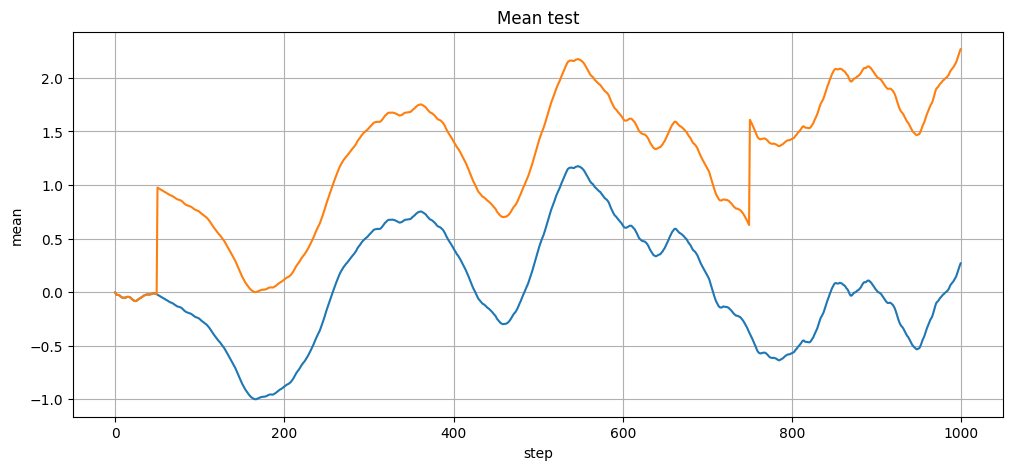

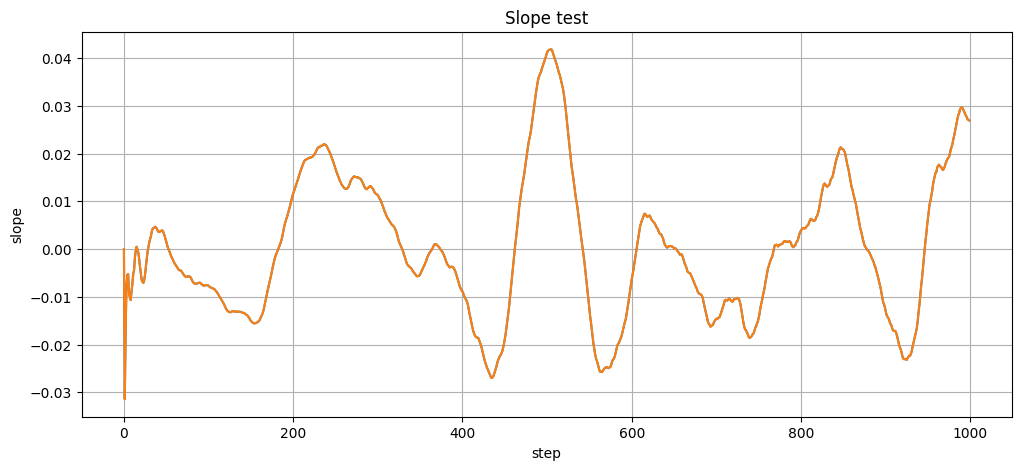

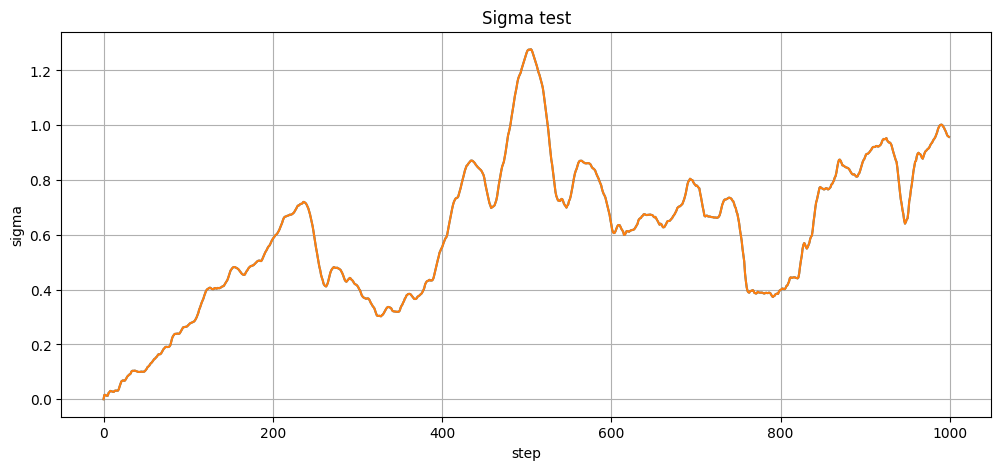

In [58]:
mean, slope, s = get_series_dynamics_clear(x,n,h)
mean1, slope1, s1 = get_series_dynamics_with_break(x,n,h,[50, 750], 1)

plt.figure(figsize=(12, 5))
plt.plot(mean)
plt.plot(mean1)
plt.xlabel('step')
plt.ylabel('mean')
plt.title('Mean test')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(slope)
plt.plot(slope1)
plt.xlabel('step')
plt.ylabel('slope')
plt.title('Slope test')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(s)
plt.plot(s1)
plt.xlabel('step')
plt.ylabel('sigma')
plt.title('Sigma test')
plt.grid(True)
plt.show()